# Proyek Analisis Data: E-Commerce Public Dataset

- **Nama:** Seni Yanti
- **Email:** seniyanti602@gmail.com
- **ID Dicoding:** CDCC206D6X1673


## Menentukan Pertanyaan Bisnis

- Bagaimana tren penjualan bulanan dari waktu ke waktu?
- Produk kategori apa yang paling banyak terjual dan menghasilkan revenue terbesar?
- Dari kota/state mana pelanggan paling banyak berasal? (geospatial)
- Siapa pelanggan terbaik berdasarkan RFM analysis?

## Import Semua Packages/Library yang Digunakan

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
from folium.plugins import HeatMap
import warnings
warnings.filterwarnings('ignore')

## Data Wrangling

### Gathering Data

In [2]:
!ls "/content/drive/MyDrive/Data Dicoding/E-commerce-public-dataset/E-Commerce Public Dataset"

ls: cannot access '/content/drive/MyDrive/Data Dicoding/E-commerce-public-dataset/E-Commerce Public Dataset': No such file or directory


In [3]:
from google.colab import drive
drive.mount('/content/drive')
folder_path = '/content/drive/MyDrive/Data Dicoding/E-commerce-public-dataset/E-Commerce Public Dataset'
os.chdir(folder_path)

Mounted at /content/drive


In [4]:
customers_df = pd.read_csv('customers_dataset.csv')
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [5]:
orders_df = pd.read_csv('orders_dataset.csv')
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [6]:
order_items_df = pd.read_csv('order_items_dataset.csv')
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [7]:
products_df = pd.read_csv('products_dataset.csv')
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [8]:
sellers_df = pd.read_csv('sellers_dataset.csv')
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [9]:
geolocation_df = pd.read_csv('geolocation_dataset.csv')
geolocation_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [10]:
order_payments_df = pd.read_csv('order_payments_dataset.csv')
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [11]:
order_reviews_df = pd.read_csv('order_reviews_dataset.csv')
order_reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [12]:
category_translation_df = pd.read_csv('product_category_name_translation.csv')
category_translation_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


**Insight:**
- Dataset terdiri dari 9 file CSV yang saling berhubungan.
  customers_dataset berisi data pelanggan dengan kolom utama
  customer_id, customer_unique_id, kota, dan state.
- orders_dataset sudah langsung menampilkan status "delivered"
  di 5 baris pertama, artinya mayoritas data memang pesanan
  yang sudah terselesaikan.
- products_dataset menyimpan nama kategori dalam bahasa Portugis
  (seperti perfumaria, esporte_lazer, bebes) sehingga perlu
  digabung dengan product_category_name_translation untuk
  mendapatkan nama kategori dalam bahasa Inggris.
- geolocation_dataset berisi koordinat latitude dan longitude
  per kode pos, terlihat kode pos 1046 muncul dua kali dengan
  koordinat berbeda — ini konfirmasi awal bahwa dataset ini
  punya duplikasi yang perlu dibersihkan.
- order_reviews_dataset banyak sekali nilai NaN di kolom
  review_comment_title dan review_comment_message, artinya
  kebanyakan pelanggan memberikan rating tanpa menulis komentar.
- product_category_name_translation berhasil memuat terjemahan
  kategori dari Portugis ke Inggris, contohnya beleza_saude
  jadi health_beauty dan cama_mesa_banho jadi bed_bath_table.

### Assessing Data

In [13]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [14]:
customers_df.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [15]:
print('Jumlah duplikasi:', customers_df.duplicated().sum())

Jumlah duplikasi: 0


In [16]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [17]:
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [18]:
print('Jumlah duplikasi:', orders_df.duplicated().sum())

Jumlah duplikasi: 0


In [19]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [20]:
order_items_df.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [21]:
print('Jumlah duplikasi:', order_items_df.duplicated().sum())

Jumlah duplikasi: 0


In [22]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [23]:
products_df.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [24]:
print('Jumlah duplikasi:', products_df.duplicated().sum())

Jumlah duplikasi: 0


In [25]:
geolocation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [26]:
geolocation_df.isna().sum()

,0
geolocation_zip_code_prefix,0
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0


In [27]:
print('Jumlah duplikasi geolocation:', geolocation_df.duplicated().sum())

Jumlah duplikasi geolocation: 261831


**Insight:**
- Beberapa kolom tanggal pada dataset orders_df masih bertipe object, sehingga perlu dikonversi ke datetime agar dapat digunakan untuk analisis berbasis waktu seperti tren dan recency.
- Missing values pada kolom tanggal pengiriman (order_approved_at, order_delivered_carrier_date, dan order_delivered_customer_date) masih dalam batas wajar, karena kemungkinan berasal dari pesanan yang belum selesai diproses atau belum sampai ke pelanggan.
- Pada products_df terdapat missing values pada atribut deskriptif seperti nama, deskripsi, dan jumlah foto produk. Namun, hal ini tidak terlalu mempengaruhi analisis utama karena tidak berkaitan langsung dengan perhitungan jumlah pesanan maupun revenue.
- Dataset geolocation_df memiliki jumlah duplikasi yang sangat besar. Hal ini kemungkinan terjadi karena satu kode pos dapat memiliki beberapa koordinat lokasi yang berbeda, sehingga perlu dilakukan penghapusan duplikasi untuk efisiensi dan konsistensi data.
- Tidak ditemukan duplikasi pada tabel utama seperti orders_df, customers_df, dan order_items_df, sehingga data dapat dianggap cukup bersih dan siap digunakan untuk proses penggabungan (merge) dan analisis lebih lanjut.

Secara keseluruhan, kualitas data sudah cukup baik dan hanya memerlukan beberapa penyesuaian minor sebelum digunakan dalam analisis lebih lanjut.

### Cleaning Data

In [28]:
datetime_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in datetime_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [29]:
orders_df = orders_df[orders_df['order_status'] == 'delivered'].copy()
print('jumlah pesanan delivered:', len(orders_df))

jumlah pesanan delivered: 96478


In [30]:
products_df = products_df.merge(category_translation_df, on='product_category_name', how='left')
products_df['product_category_name_english'].fillna('others', inplace=True)
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [31]:
geolocation_df.drop_duplicates(subset='geolocation_zip_code_prefix', inplace=True)
print('geolocation setelah dibersihkan:', len(geolocation_df))

geolocation setelah dibersihkan: 19015


In [32]:
all_df = orders_df.merge(order_items_df, on='order_id', how='left')
all_df = all_df.merge(products_df[['product_id', 'product_category_name_english']], on='product_id', how='left')
all_df = all_df.merge(customers_df, on='customer_id', how='left')
all_df = all_df.merge(
    geolocation_df[['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']],
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)
all_df['order_year_month'] = all_df['order_purchase_timestamp'].dt.to_period('M').astype(str)
all_df['revenue'] = all_df['price'] + all_df['freight_value']
print(all_df.shape)
all_df.head()

(110197, 24)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_category_name_english,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,order_year_month,revenue
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,housewares,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,3149.0,-23.574809,-46.587471,2017-10,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,perfumery,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,47813.0,-12.169860,-44.988369,2018-07,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,auto,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,75265.0,-16.746337,-48.514624,2018-08,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,pet_shop,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,59296.0,-5.767733,-35.275467,2017-11,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,...,stationery,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,9195.0,-23.675037,-46.524784,2018-02,28.62


**Insight:**
- Setelah dilakukan filtering hanya pada pesanan dengan status "delivered", dataset menjadi lebih representatif untuk analisis karena hanya mencakup transaksi yang benar-benar selesai. Hal ini penting untuk menghindari bias dari pesanan yang dibatalkan atau masih dalam proses.
- Proses penggabungan (merge) beberapa tabel berhasil menghasilkan satu dataframe utama (all_df) yang mengintegrasikan informasi pelanggan, produk, transaksi, dan lokasi. Data ini sudah cukup lengkap untuk mendukung analisis EDA dan visualisasi lebih lanjut.
- Variabel revenue dihitung sebagai penjumlahan antara price dan freight_value, sehingga mencerminkan total nilai transaksi yang dibayarkan pelanggan, termasuk biaya pengiriman. Pendefinisian ini penting agar analisis revenue lebih realistis dari sisi bisnis.
- Setelah dilakukan penggabungan dengan data geolocation, ditemukan beberapa baris dengan informasi lokasi yang tidak lengkap. Hal ini kemungkinan disebabkan oleh ketidaksesuaian kode pos antara dataset pelanggan dan geolokasi, namun jumlahnya relatif kecil sehingga tidak berdampak signifikan terhadap keseluruhan analisis.

Secara keseluruhan, data telah melalui proses pembersihan dan integrasi dengan baik sehingga siap digunakan untuk analisis eksploratif dan menjawab pertanyaan bisnis yang telah ditentukan.

## Exploratory Data Analysis (EDA)

### Explore Tren Pesanan Bulanan

In [33]:
monthly_df = all_df.groupby('order_year_month').agg(
    order_count=('order_id', 'nunique'),
    total_revenue=('revenue', 'sum')
).reset_index()

monthly_df.describe()

,order_count,total_revenue
count,23.000000,2.300000e+01
mean,4194.695652,6.704249e+05
std,2481.181398,3.951328e+05
min,1.000000,1.962000e+01
25%,2424.500000,4.025717e+05
50%,4193.000000,7.010775e+05
75%,6453.000000,1.019893e+06
max,7289.000000,1.153364e+06


In [34]:
print('bulan paling ramai:', monthly_df.loc[monthly_df['order_count'].idxmax(), 'order_year_month'])
print('bulan paling sepi:', monthly_df.loc[monthly_df['order_count'].idxmin(), 'order_year_month'])

bulan paling ramai: 2017-11
bulan paling sepi: 2016-09


### Explore Kategori Produk

In [35]:
category_agg = all_df.groupby('product_category_name_english').agg(
    total_orders=('order_id', 'count'),
    total_revenue=('revenue', 'sum')
).reset_index().sort_values('total_orders', ascending=False)

category_agg.head(10)

,product_category_name_english,total_orders,total_revenue
7,bed_bath_table,10953,1225209.26
43,health_beauty,9465,1412089.53
66,sports_leisure,8431,1118256.91
39,furniture_decor,8160,880329.92
15,computers_accessories,7644,1032723.77
49,housewares,6795,758392.25
71,watches_gifts,5859,1264333.12
69,telephony,4430,379202.62
42,garden_tools,4268,567145.68
5,auto,4140,669454.75


### Explore Distribusi Pelanggan

In [36]:
bystate_df = all_df.groupby('customer_state').customer_unique_id.nunique().sort_values(ascending=False).reset_index()
bystate_df.columns = ['customer_state', 'customer_count']
bystate_df.head(10)

,customer_state,customer_count
0,SP,39156
1,RJ,11917
2,MG,11001
3,RS,5168
4,PR,4769
5,SC,3449
6,BA,3158
7,DF,2019
8,ES,1928
9,GO,1895


In [37]:
bycity_df = all_df.groupby('customer_city').customer_unique_id.nunique().sort_values(ascending=False).reset_index()
bycity_df.columns = ['customer_city', 'customer_count']
bycity_df.head(10)

,customer_city,customer_count
0,sao paulo,14528
1,rio de janeiro,6361
2,belo horizonte,2606
3,brasilia,2013
4,curitiba,1434
5,campinas,1363
6,porto alegre,1292
7,salvador,1154
8,guarulhos,1111
9,sao bernardo do campo,881


**Insight:**
- Berdasarkan agregasi bulanan, jumlah pesanan memiliki rata-rata sekitar 4.194 order per bulan dengan variasi yang cukup tinggi (std ≈ 2.481). Hal ini menunjukkan adanya fluktuasi permintaan yang signifikan antar bulan.
- Ditemukan bahwa bulan dengan jumlah pesanan tertinggi terjadi pada November 2017, sedangkan yang terendah pada September 2016. Lonjakan pada akhir tahun mengindikasikan adanya pola musiman (seasonality), kemungkinan dipengaruhi oleh event promosi seperti Black Friday atau akhir tahun.
- Dari sisi kategori produk, kategori bed_bath_table dan health_beauty mendominasi jumlah pesanan, menunjukkan bahwa kebutuhan rumah tangga dan personal care memiliki demand yang tinggi. Namun, beberapa kategori seperti electronics (misalnya computers_accessories) tetap memberikan kontribusi revenue yang besar meskipun volume transaksi tidak sebanyak kategori utama, yang mengindikasikan adanya perbedaan nilai transaksi per kategori.
- Distribusi pelanggan berdasarkan wilayah menunjukkan konsentrasi yang sangat tinggi di state SP (Sao Paulo), yang jauh melampaui state lainnya seperti RJ dan MG. Hal ini menunjukkan bahwa pasar utama platform ini terpusat di wilayah tersebut.
- Pada level kota, Sao Paulo menjadi kota dengan jumlah pelanggan tertinggi secara signifikan, diikuti oleh Rio de Janeiro dan Belo Horizonte. Distribusi ini mengindikasikan bahwa aktivitas transaksi e-commerce cenderung terkonsentrasi di kota-kota besar (urban area).
- Secara keseluruhan, data menunjukkan adanya pola musiman dalam transaksi, dominasi kategori tertentu dalam volume penjualan, serta konsentrasi geografis pelanggan yang tinggi, yang semuanya berpotensi menjadi dasar dalam pengambilan keputusan bisnis seperti strategi promosi, distribusi produk, dan ekspansi pasar.

Insight ini menunjukkan bahwa analisis tidak hanya memberikan gambaran deskriptif, tetapi juga mampu mengidentifikasi pola perilaku pelanggan dan peluang strategis bagi bisnis.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren penjualan bulanan dari waktu ke waktu?


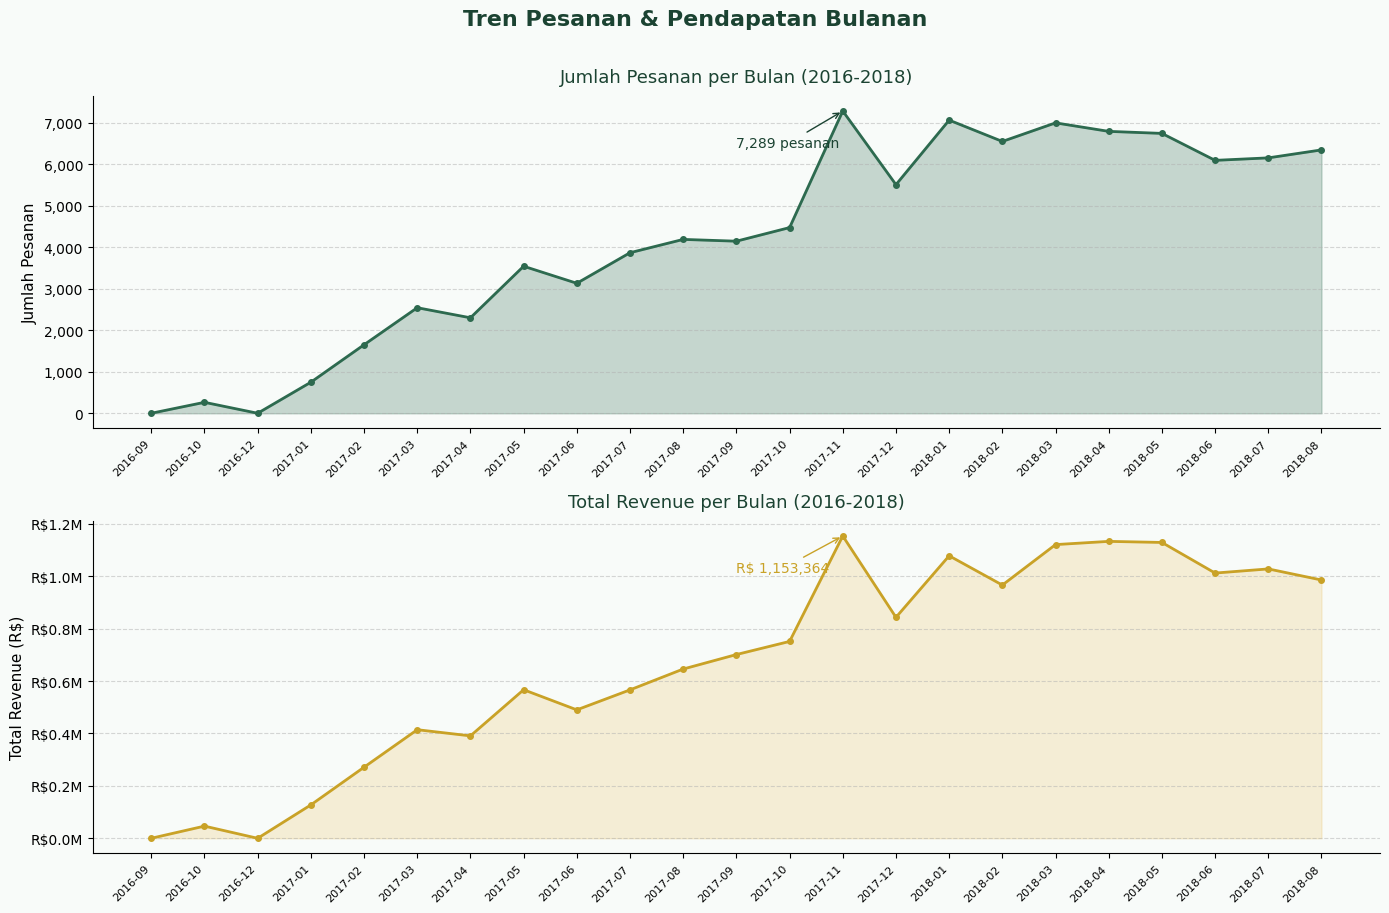

In [38]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.patch.set_facecolor('#F8FBF9')

x = range(len(monthly_df))

# plot jumlah pesanan
axes[0].set_facecolor('#F8FBF9')
axes[0].fill_between(x, monthly_df['order_count'], alpha=0.25, color='#2D6A4F')
axes[0].plot(x, monthly_df['order_count'], color='#2D6A4F', linewidth=2, marker='o', markersize=4)

peak = monthly_df['order_count'].idxmax()
axes[0].annotate(
    f"{monthly_df.loc[peak,'order_count']:,} pesanan",
    xy=(peak, monthly_df.loc[peak,'order_count']),
    xytext=(peak-2, monthly_df.loc[peak,'order_count'] * 0.88),
    arrowprops=dict(arrowstyle='->', color='#1B4332'),
    fontsize=10, color='#1B4332'
)

axes[0].set_xticks(x)
axes[0].set_xticklabels(monthly_df['order_year_month'], rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Jumlah Pesanan', fontsize=11)
axes[0].set_title('Jumlah Pesanan per Bulan (2016-2018)', fontsize=13, color='#1B4332', pad=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# plot total revenue
axes[1].set_facecolor('#F8FBF9')
axes[1].fill_between(x, monthly_df['total_revenue'], alpha=0.25, color='#E9C46A')
axes[1].plot(x, monthly_df['total_revenue'], color='#C9A227', linewidth=2, marker='o', markersize=4)

peak_rev = monthly_df['total_revenue'].idxmax()
axes[1].annotate(
    f"R$ {monthly_df.loc[peak_rev,'total_revenue']:,.0f}",
    xy=(peak_rev, monthly_df.loc[peak_rev,'total_revenue']),
    xytext=(peak_rev-2, monthly_df.loc[peak_rev,'total_revenue'] * 0.88),
    arrowprops=dict(arrowstyle='->', color='#C9A227'),
    fontsize=10, color='#C9A227'
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(monthly_df['order_year_month'], rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Total Revenue (R$)', fontsize=11)
axes[1].set_title('Total Revenue per Bulan (2016-2018)', fontsize=13, color='#1B4332', pad=10)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Tren Pesanan & Pendapatan Bulanan', fontsize=16, fontweight='bold', color='#1B4332', y=1.01)
plt.tight_layout()
plt.savefig('tren_bulanan.png', dpi=150, bbox_inches='tight')
plt.show()

### Pertanyaan 2: Produk kategori apa yang paling banyak terjual dan menghasilkan revenue terbesar?

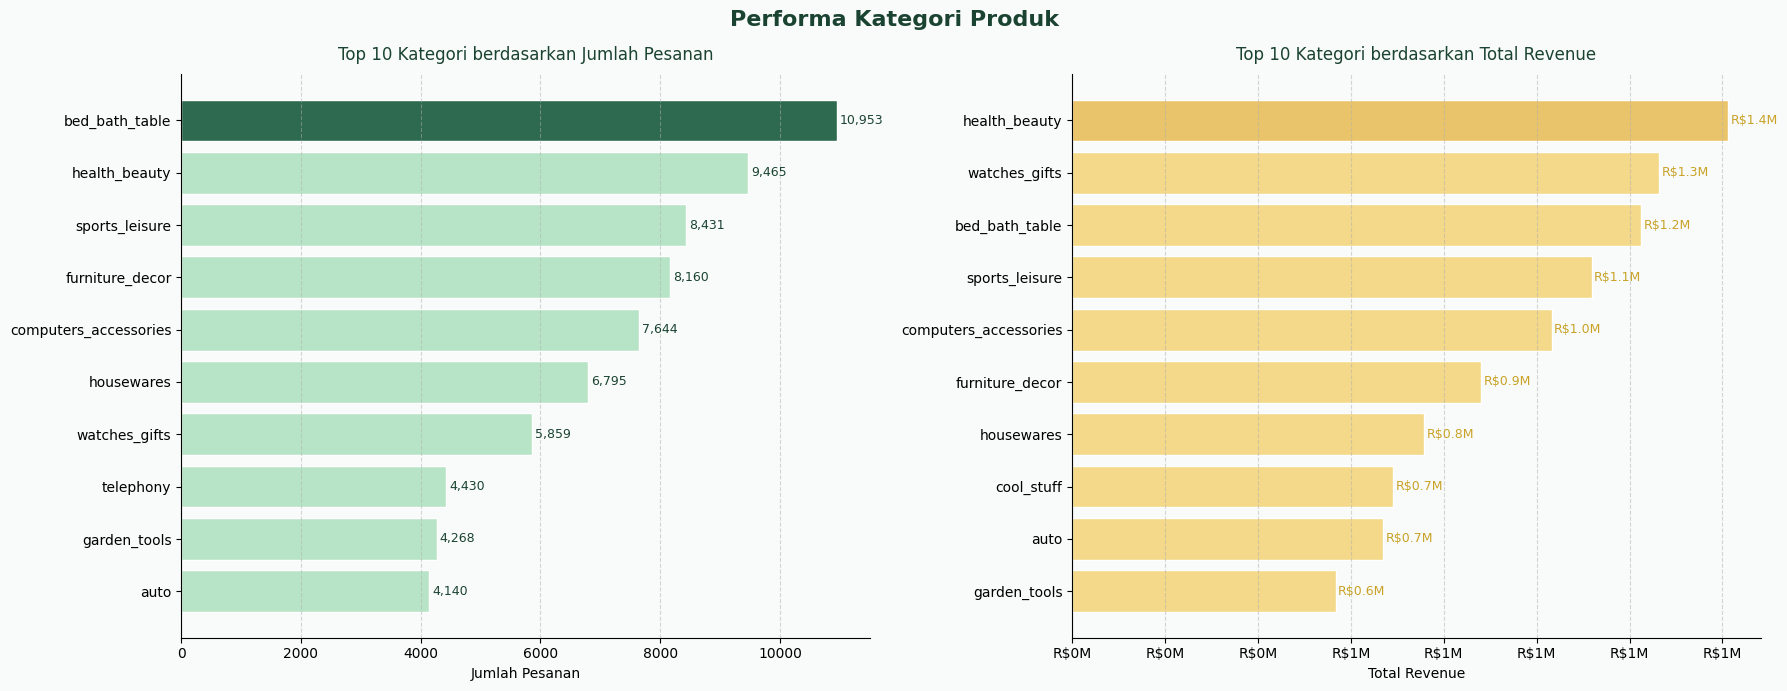

In [39]:
top10_orders = category_agg.head(10)
top10_revenue = category_agg.sort_values('total_revenue', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#F8FBF9')

# bar kiri - jumlah pesanan
colors_l = ['#2D6A4F' if i == 0 else '#B7E4C7' for i in range(10)]
axes[0].set_facecolor('#F8FBF9')
bars1 = axes[0].barh(
    top10_orders['product_category_name_english'][::-1],
    top10_orders['total_orders'][::-1],
    color=colors_l[::-1],
    edgecolor='white'
)
for bar in bars1:
    w = bar.get_width()
    axes[0].text(w + 50, bar.get_y() + bar.get_height()/2,
                 f'{int(w):,}', va='center', ha='left', fontsize=9, color='#1B4332')
axes[0].set_title('Top 10 Kategori berdasarkan Jumlah Pesanan', fontsize=12, color='#1B4332', pad=10)
axes[0].set_xlabel('Jumlah Pesanan')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

# bar kanan - revenue
colors_r = ['#E9C46A' if i == 0 else '#F4D98A' for i in range(10)]
axes[1].set_facecolor('#F8FBF9')
bars2 = axes[1].barh(
    top10_revenue['product_category_name_english'][::-1],
    top10_revenue['total_revenue'][::-1],
    color=colors_r[::-1],
    edgecolor='white'
)
for bar in bars2:
    w = bar.get_width()
    axes[1].text(w + 5000, bar.get_y() + bar.get_height()/2,
                 f'R${w/1e6:.1f}M', va='center', ha='left', fontsize=9, color='#C9A227')
axes[1].set_title('Top 10 Kategori berdasarkan Total Revenue', fontsize=12, color='#1B4332', pad=10)
axes[1].set_xlabel('Total Revenue')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.0f}M'))
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.suptitle('Performa Kategori Produk', fontsize=16, fontweight='bold', color='#1B4332')
plt.tight_layout()
plt.savefig('kategori_produk.png', dpi=150, bbox_inches='tight')
plt.show()

### Pertanyaan 3: Dari kota/state mana pelanggan paling banyak berasal?

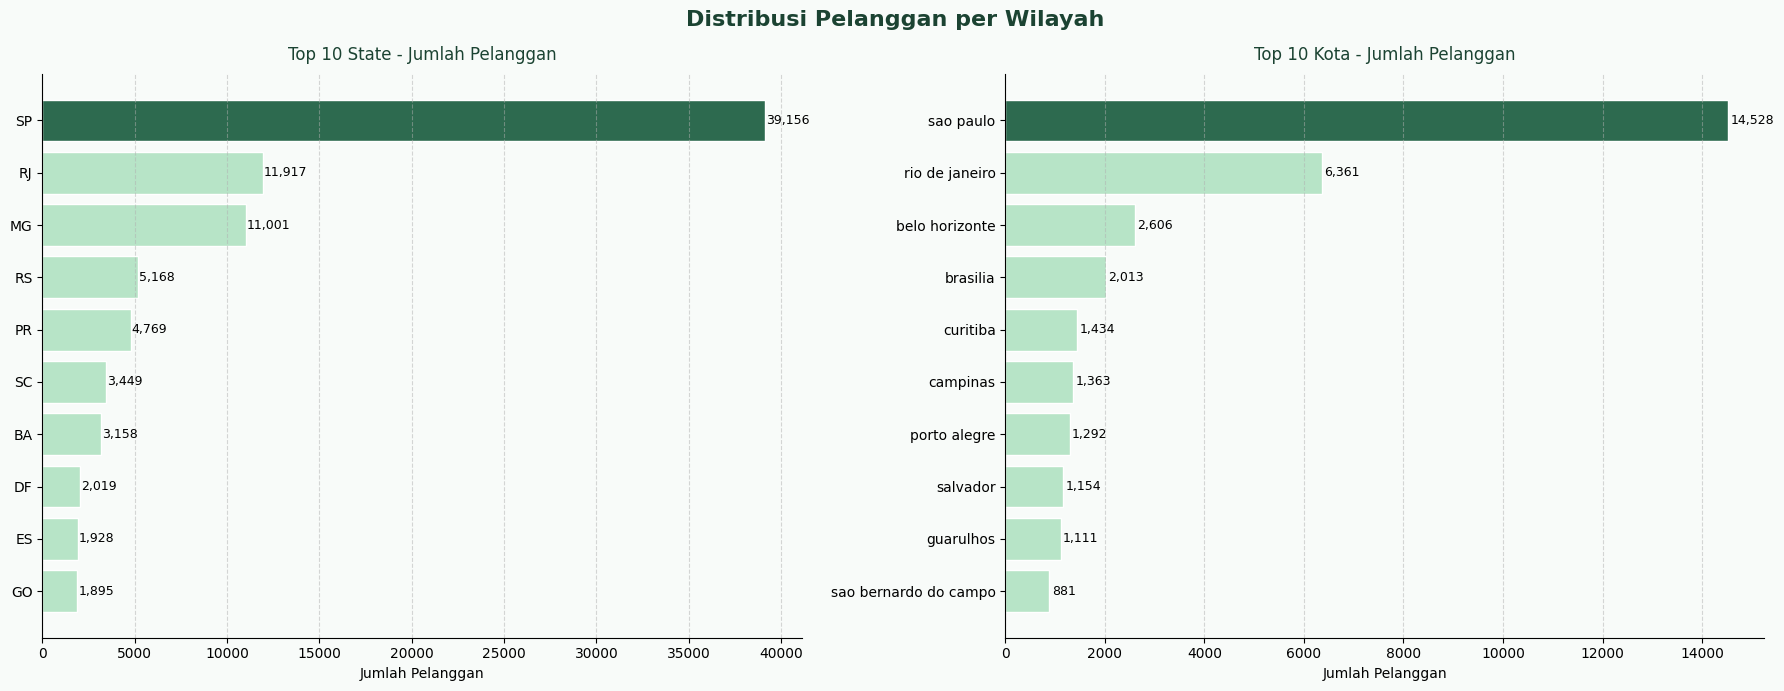

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#F8FBF9')

top10_state = bystate_df.head(10)
colors_s = ['#2D6A4F' if i == 0 else '#B7E4C7' for i in range(10)]
axes[0].set_facecolor('#F8FBF9')
bars = axes[0].barh(
    top10_state['customer_state'][::-1],
    top10_state['customer_count'][::-1],
    color=colors_s[::-1], edgecolor='white'
)
for bar in bars:
    w = bar.get_width()
    axes[0].text(w + 50, bar.get_y() + bar.get_height()/2,
                 f'{int(w):,}', va='center', ha='left', fontsize=9)
axes[0].set_title('Top 10 State - Jumlah Pelanggan', fontsize=12, color='#1B4332', pad=10)
axes[0].set_xlabel('Jumlah Pelanggan')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

top10_city = bycity_df.head(10)
colors_c = ['#2D6A4F' if i == 0 else '#B7E4C7' for i in range(10)]
axes[1].set_facecolor('#F8FBF9')
bars2 = axes[1].barh(
    top10_city['customer_city'][::-1],
    top10_city['customer_count'][::-1],
    color=colors_c[::-1], edgecolor='white'
)
for bar in bars2:
    w = bar.get_width()
    axes[1].text(w + 50, bar.get_y() + bar.get_height()/2,
                 f'{int(w):,}', va='center', ha='left', fontsize=9)
axes[1].set_title('Top 10 Kota - Jumlah Pelanggan', fontsize=12, color='#1B4332', pad=10)
axes[1].set_xlabel('Jumlah Pelanggan')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.suptitle('Distribusi Pelanggan per Wilayah', fontsize=16, fontweight='bold', color='#1B4332')
plt.tight_layout()
plt.savefig('distribusi_wilayah.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Visualisasi tren bulanan menunjukkan bahwa jumlah pesanan dan total revenue memiliki pola yang searah (positively correlated), di mana ketika jumlah pesanan meningkat, revenue juga ikut meningkat. Hal ini mengindikasikan bahwa pertumbuhan bisnis tidak hanya berasal dari peningkatan harga, tetapi juga dari peningkatan volume transaksi.
- Terlihat adanya tren kenaikan yang cukup konsisten dari tahun 2016 hingga puncaknya di akhir 2017. Lonjakan signifikan pada November 2017 mengindikasikan adanya efek musiman (seasonality), yang kemungkinan besar dipicu oleh event promosi besar seperti Black Friday atau kampanye akhir tahun.
- Setelah periode puncak, tren mengalami sedikit fluktuasi namun tetap berada pada level yang relatif tinggi. Hal ini menunjukkan bahwa meskipun terdapat penurunan setelah peak season, performa bisnis tetap stabil dan tidak kembali ke level awal.
- Pada analisis kategori produk, kategori bed_bath_table memiliki jumlah pesanan tertinggi, yang menunjukkan tingginya demand untuk kebutuhan rumah tangga. Namun, kategori seperti health_beauty dan watches_gifts menghasilkan revenue yang lebih tinggi, mengindikasikan bahwa produk dalam kategori tersebut memiliki nilai transaksi rata-rata (average order value) yang lebih besar.
- Perbedaan antara kategori dengan jumlah pesanan tinggi dan kategori dengan revenue tinggi menunjukkan adanya segmentasi produk, di mana beberapa kategori berperan sebagai high-volume (banyak transaksi) dan lainnya sebagai high-value (nilai transaksi besar).
- Dari sisi distribusi pelanggan, terlihat bahwa pelanggan sangat terpusat di state SP (Sao Paulo), dengan jumlah yang jauh lebih tinggi dibandingkan state lain. Hal ini menunjukkan bahwa wilayah tersebut merupakan pasar utama yang memiliki kontribusi terbesar terhadap aktivitas transaksi.
- Pada level kota, Sao Paulo juga mendominasi secara signifikan, diikuti oleh Rio de Janeiro dan Belo Horizonte. Pola ini mengindikasikan bahwa aktivitas e-commerce lebih terkonsentrasi di kota metropolitan dengan tingkat populasi dan aktivitas ekonomi yang tinggi.

Secara keseluruhan, visualisasi ini mengungkap adanya pola pertumbuhan, seasonality, perbedaan karakteristik antar kategori produk, serta konsentrasi geografis pelanggan, yang semuanya penting untuk strategi bisnis seperti penentuan target pasar, optimalisasi promosi, dan pengelolaan produk.

Dengan menggabungkan analisis tren, kategori, dan distribusi pelanggan, model analisis ini memberikan gambaran komprehensif terhadap pola perilaku konsumen serta peluang optimasi bisnis berbasis data.

## Analisis Lanjutan (Opsional)

###RFM ANALYSIS
###Pertanyaan 4: Siapa pelanggan terbaik berdasarkan RFM analysis

RFM Analysis digunakan untuk mengelompokkan pelanggan berdasarkan tiga hal:
- Recency (seberapa baru mereka belanja)
- Frequency (seberapa sering mereka belanja)
- Monetary (seberapa total belanjanya)
Tujuannya supaya bisa tau pelanggan mana yang paling berharga dan mana yang perlu diperhatikan.

In [41]:
snapshot_date = all_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm_df = all_df.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('revenue', 'sum')
).reset_index()

rfm_df.head()

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


In [42]:
rfm_df['r_score'] = pd.qcut(rfm_df['recency'], q=5, labels=[5, 4, 3, 2, 1])
rfm_df['f_score'] = pd.qcut(rfm_df['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm_df['m_score'] = pd.qcut(rfm_df['monetary'], q=5, labels=[1, 2, 3, 4, 5])

rfm_df['rfm_score'] = rfm_df[['r_score', 'f_score', 'm_score']].astype(int).sum(axis=1)
rfm_df.describe()

,recency,frequency,monetary,rfm_score
count,93358.000000,93358.000000,93358.000000,93358.000000
mean,237.941773,1.033420,165.168210,9.003213
std,152.591453,0.209097,226.292101,2.499327
min,1.000000,1.000000,9.590000,3.000000
25%,114.000000,1.000000,63.010000,7.000000
50%,219.000000,1.000000,107.780000,9.000000
75%,346.000000,1.000000,182.510000,11.000000
max,714.000000,15.000000,13664.080000,15.000000


In [43]:
def segment_customer(score):
    if score >= 13:
        return 'Champions'
    elif score >= 10:
        return 'Loyal Customers'
    elif score >= 7:
        return 'Potential Loyalists'
    elif score >= 4:
        return 'At Risk'
    else:
        return 'Lost'

rfm_df['segment'] = rfm_df['rfm_score'].apply(segment_customer)
rfm_df['segment'].value_counts()

,count
segment,
Potential Loyalists,38382
Loyal Customers,31508
At Risk,14636
Champions,8033
Lost,799


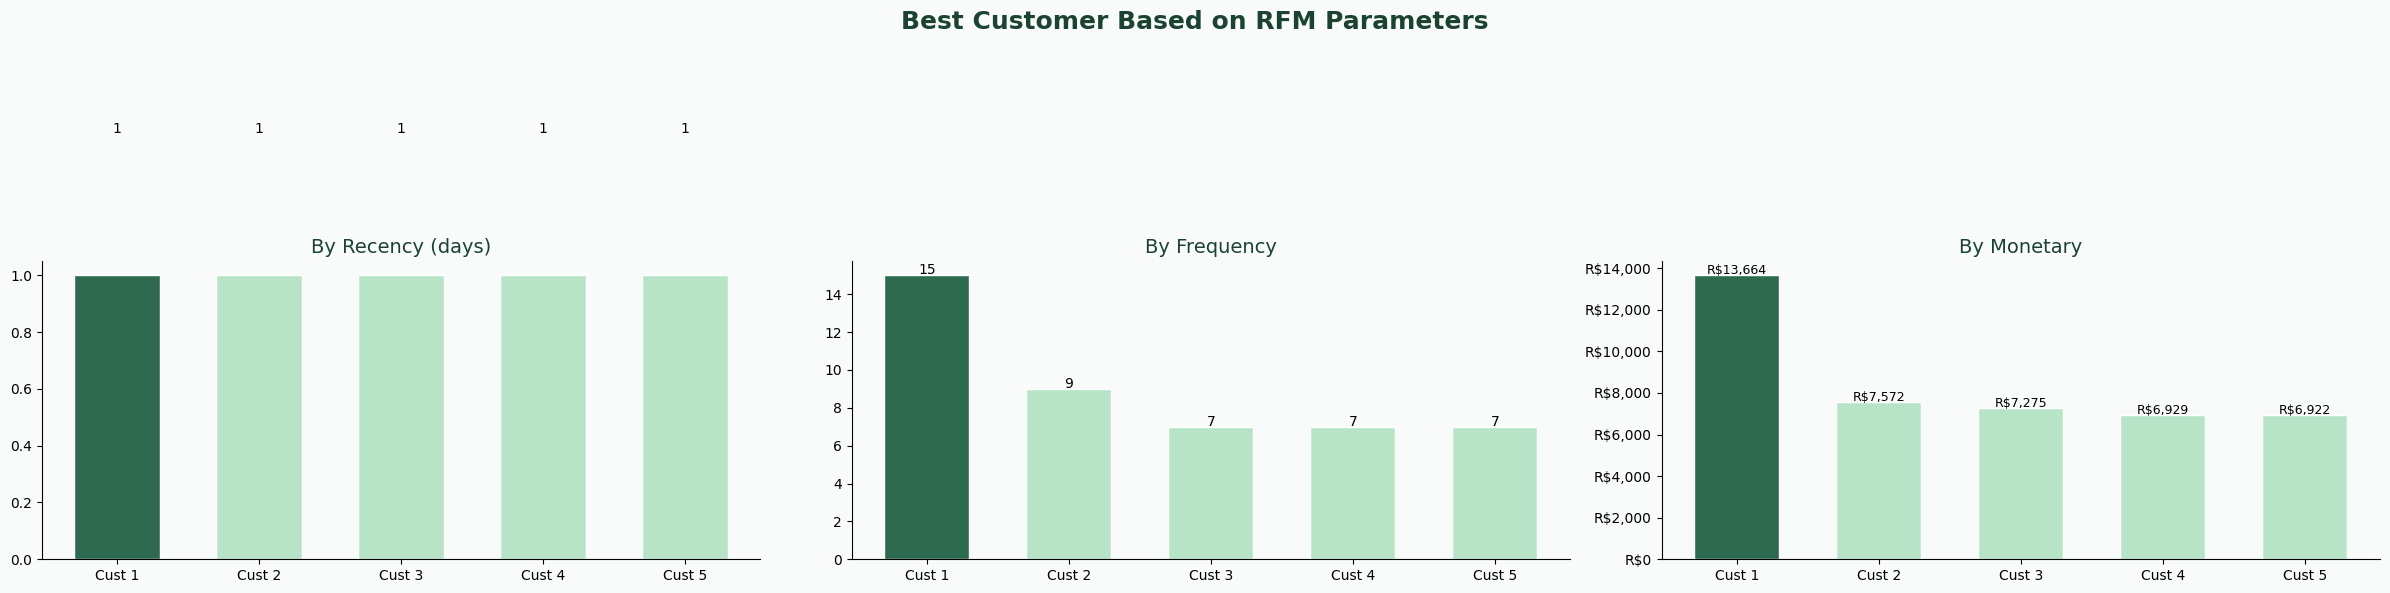

In [44]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(24, 6))
fig.patch.set_facecolor('#F8FBF9')

colors = ['#2D6A4F', '#B7E4C7', '#B7E4C7', '#B7E4C7', '#B7E4C7']

top5_recency = rfm_df.sort_values('recency', ascending=True).head(5)
ax[0].set_facecolor('#F8FBF9')
bars0 = ax[0].bar(range(5), top5_recency['recency'].values, color=colors, edgecolor='white', width=0.6)
ax[0].set_xticks(range(5))
ax[0].set_xticklabels([f'Cust {i+1}' for i in range(5)], fontsize=10)
ax[0].set_title('By Recency (days)', fontsize=14, color='#1B4332')
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
for bar in bars0:
    ax[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
               f'{int(bar.get_height())}', ha='center', fontsize=10)

top5_freq = rfm_df.sort_values('frequency', ascending=False).head(5)
ax[1].set_facecolor('#F8FBF9')
bars1 = ax[1].bar(range(5), top5_freq['frequency'].values, color=colors, edgecolor='white', width=0.6)
ax[1].set_xticks(range(5))
ax[1].set_xticklabels([f'Cust {i+1}' for i in range(5)], fontsize=10)
ax[1].set_title('By Frequency', fontsize=14, color='#1B4332')
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
for bar in bars1:
    ax[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
               f'{int(bar.get_height())}', ha='center', fontsize=10)

top5_monetary = rfm_df.sort_values('monetary', ascending=False).head(5)
ax[2].set_facecolor('#F8FBF9')
bars2 = ax[2].bar(range(5), top5_monetary['monetary'].values, color=colors, edgecolor='white', width=0.6)
ax[2].set_xticks(range(5))
ax[2].set_xticklabels([f'Cust {i+1}' for i in range(5)], fontsize=10)
ax[2].set_title('By Monetary', fontsize=14, color='#1B4332')
ax[2].spines['top'].set_visible(False)
ax[2].spines['right'].set_visible(False)
ax[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
for bar in bars2:
    ax[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
               f'R${bar.get_height():,.0f}', ha='center', fontsize=9)

plt.suptitle('Best Customer Based on RFM Parameters', fontsize=18, fontweight='bold', color='#1B4332')
plt.tight_layout()
plt.savefig('rfm_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

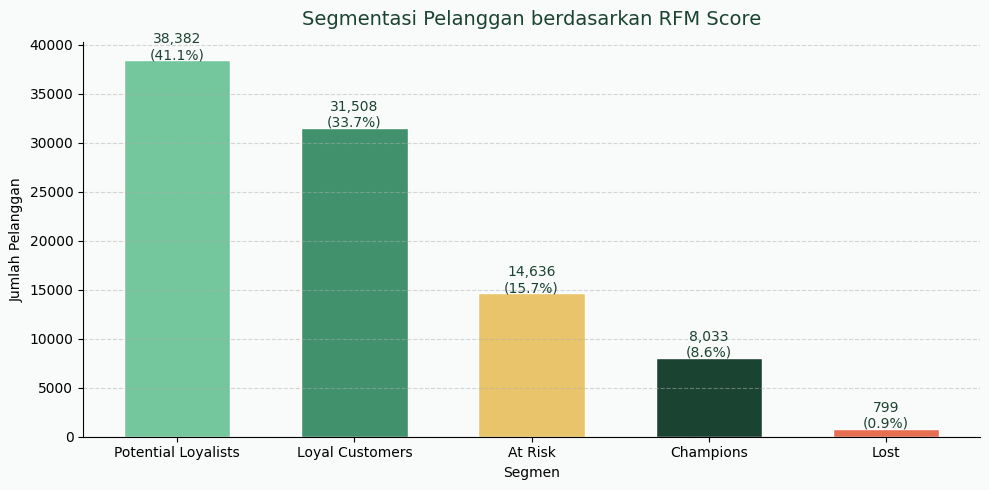

In [45]:
seg_counts = rfm_df['segment'].value_counts().reset_index()
seg_counts.columns = ['segment', 'count']

seg_colors = {
    'Champions': '#1B4332',
    'Loyal Customers': '#40916C',
    'Potential Loyalists': '#74C69D',
    'At Risk': '#E9C46A',
    'Lost': '#E76F51'
}

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#F8FBF9')
ax.set_facecolor('#F8FBF9')

bars = ax.bar(
    seg_counts['segment'],
    seg_counts['count'],
    color=[seg_colors.get(s, '#2D6A4F') for s in seg_counts['segment']],
    edgecolor='white',
    width=0.6
)
for bar in bars:
    h = bar.get_height()
    pct = h / seg_counts['count'].sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2, h + 100,
            f'{int(h):,}\n({pct:.1f}%)', ha='center', fontsize=10, color='#1B4332')

ax.set_title('Segmentasi Pelanggan berdasarkan RFM Score', fontsize=14, color='#1B4332', pad=12)
ax.set_xlabel('Segmen')
ax.set_ylabel('Jumlah Pelanggan')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('rfm_segmentasi.png', dpi=150, bbox_inches='tight')
plt.show()

###GEOSPATIAL ANALYSIS


Analisis geospatial digunakan untuk melihat sebaran pelanggan secara geografis berdasarkan koordinat latitude dan longitude. Dengan visualisasi peta, kita bisa dengan mudah melihat di wilayah mana konsentrasi pelanggan paling tinggi.

In [46]:
geo_customers = all_df[['customer_unique_id', 'geolocation_lat', 'geolocation_lng']].dropna().drop_duplicates(subset='customer_unique_id')
print('jumlah pelanggan dengan koordinat:', len(geo_customers))
geo_customers.head()


jumlah pelanggan dengan koordinat: 93104


,customer_unique_id,geolocation_lat,geolocation_lng
0,7c396fd4830fd04220f754e42b4e5bff,-23.574809,-46.587471
1,af07308b275d755c9edb36a90c618231,-12.169860,-44.988369
2,3a653a41f6f9fc3d2a113cf8398680e8,-16.746337,-48.514624
3,7c142cf63193a1473d2e66489a9ae977,-5.767733,-35.275467
4,72632f0f9dd73dfee390c9b22eb56dd6,-23.675037,-46.524784


In [47]:
m = folium.Map(location=[-14.2350, -51.9253], zoom_start=4, tiles='CartoDB positron')

heat_data = geo_customers[['geolocation_lat', 'geolocation_lng']].values.tolist()

HeatMap(
    heat_data,
    min_opacity=0.3,
    radius=8,
    blur=10,
    gradient={0.4: '#74C69D', 0.65: '#40916C', 1.0: '#1B4332'}
).add_to(m)

m.save('geospatial_customers.html')
m

###CLUSTERING MANUAL


Pengelompokan pelanggan berdasarkan skor RFM tanpa machine learning. Teknik ini menggunakan binning manual untuk menentukan segmen pelanggan berdasarkan aturan bisnis yang sudah ditetapkan sebelumnya.

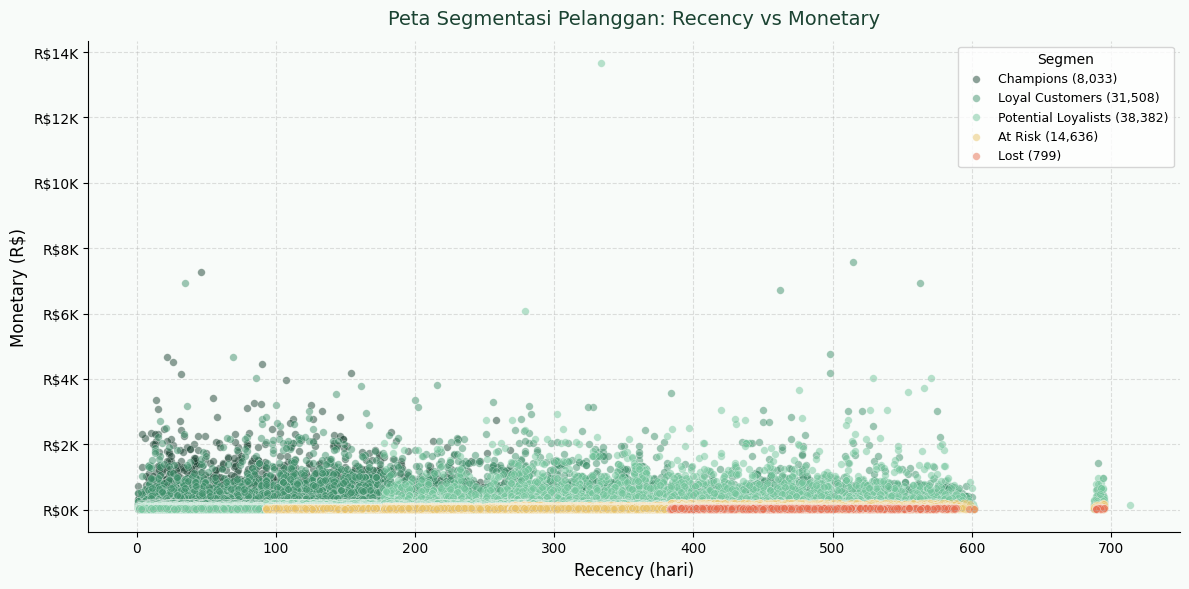

In [48]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#F8FBF9')
ax.set_facecolor('#F8FBF9')

seg_palette = {
    'Champions': '#1B4332',
    'Loyal Customers': '#40916C',
    'Potential Loyalists': '#74C69D',
    'At Risk': '#E9C46A',
    'Lost': '#E76F51'
}

for segment, color in seg_palette.items():
    subset = rfm_df[rfm_df['segment'] == segment]
    ax.scatter(
        subset['recency'],
        subset['monetary'],
        c=color,
        label=f'{segment} ({len(subset):,})',
        alpha=0.5,
        s=30,
        edgecolors='white',
        linewidth=0.3
    )

ax.set_xlabel('Recency (hari)', fontsize=12)
ax.set_ylabel('Monetary (R$)', fontsize=12)
ax.set_title('Peta Segmentasi Pelanggan: Recency vs Monetary', fontsize=14, color='#1B4332', pad=12)
ax.legend(title='Segmen', fontsize=9, loc='upper right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e3:.0f}K'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('rfm_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

In [49]:
all_df.to_csv('main_data.csv', index=False)
print('main_data.csv berhasil disimpan')

main_data.csv berhasil disimpan


## Conclusion

- Conclution pertanyaan 1
Berdasarkan analisis tren penjualan, terlihat bahwa jumlah pesanan dan total revenue mengalami peningkatan yang konsisten dari tahun 2016 hingga mencapai puncaknya pada akhir 2017. Pola ini menunjukkan adanya pertumbuhan bisnis yang stabil serta indikasi seasonality, di mana lonjakan signifikan terjadi pada periode tertentu seperti event promosi besar. Setelah periode puncak, performa cenderung stabil meskipun mengalami sedikit fluktuasi.
- Conclution pertanyaan 2
Dari sisi kategori produk, kategori bed_bath_table menjadi yang paling unggul dalam jumlah pesanan, menunjukkan tingginya kebutuhan pelanggan terhadap produk rumah tangga. Namun, kategori seperti health_beauty dan watches_gifts memberikan kontribusi revenue yang lebih besar, yang mengindikasikan adanya perbedaan antara produk dengan volume tinggi dan produk dengan nilai transaksi tinggi (high-value products).
- Conclution pertanyaan 3
Analisis distribusi pelanggan menunjukkan bahwa mayoritas pelanggan berasal dari state Sao Paulo (SP), dengan konsentrasi tertinggi di kota Sao Paulo, diikuti oleh kota besar lainnya seperti Rio de Janeiro dan Belo Horizonte. Hal ini menunjukkan bahwa aktivitas e-commerce sangat terpusat di wilayah metropolitan dengan tingkat ekonomi yang tinggi.
- Conclution pertanyaan 4
Berdasarkan analisis RFM, sebagian besar pelanggan berada pada segmen Potential Loyalists dan Loyal Customers, yang menunjukkan bahwa perusahaan memiliki basis pelanggan yang cukup aktif dan berpotensi untuk dipertahankan. Segmen Champions meskipun jumlahnya lebih kecil, merupakan pelanggan dengan nilai tertinggi dan perlu dijaga loyalitasnya. Sementara itu, segmen At Risk dan Lost menunjukkan adanya pelanggan yang mulai tidak aktif dan berpotensi churn.

Visualisasi geospasial memperkuat temuan sebelumnya, di mana konsentrasi pelanggan terlihat lebih padat di wilayah Brazil bagian tenggara, khususnya di sekitar Sao Paulo. Hal ini memperjelas bahwa distribusi pelanggan tidak merata dan terfokus pada area tertentu.
Secara keseluruhan, analisis ini menunjukkan bahwa bisnis memiliki pertumbuhan yang baik, segmentasi pelanggan yang jelas, serta peluang besar dalam optimalisasi strategi pemasaran, khususnya pada pengelolaan pelanggan loyal dan ekspansi ke wilayah dengan potensi yang belum maksimal.

- Fokus mempertahankan pelanggan pada segmen Champions dan Loyal Customers melalui program loyalitas atau reward.
- Melakukan re-engagement campaign untuk segmen At Risk dan Lost, seperti diskon atau notifikasi personal.
- Mengoptimalkan promosi pada kategori dengan revenue tinggi untuk meningkatkan profit.
- Mengeksplorasi ekspansi pasar di luar wilayah Sao Paulo untuk memperluas jangkauan bisnis.